In [3]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine, load_iris, load_breast_cancer, fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from mpl_toolkits.mplot3d import Axes3D
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis





### zad 1

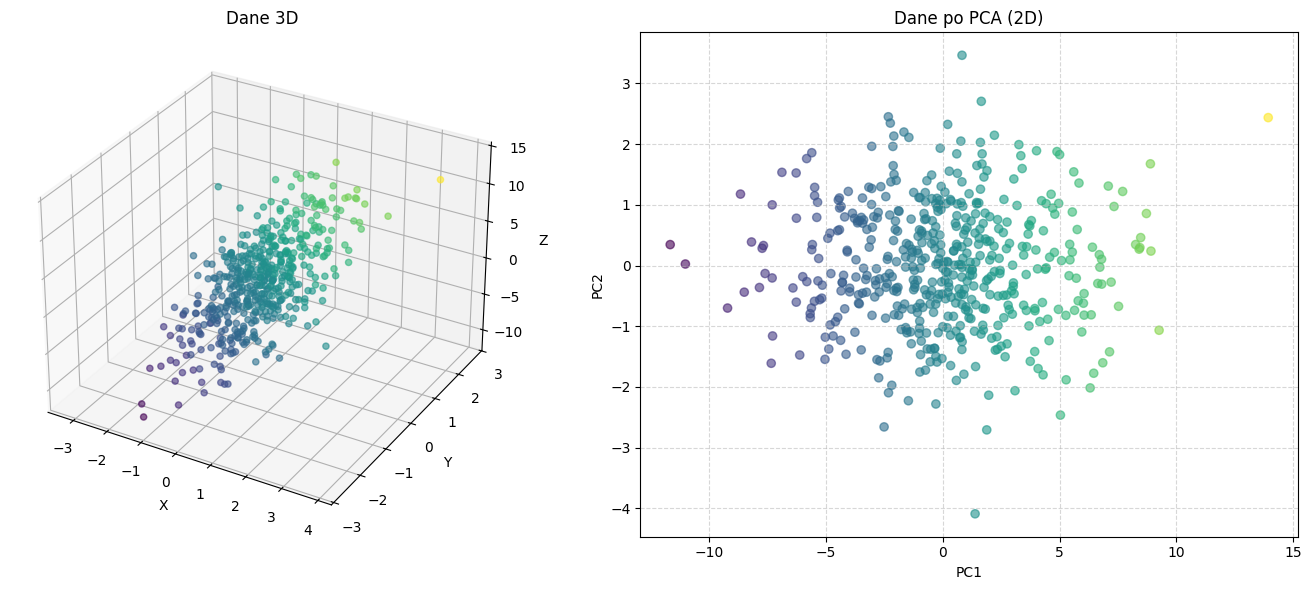

In [4]:
np.random.seed(42)
n_samples = 500

x = np.random.normal(0, 1, n_samples)
y = np.random.normal(0, 1, n_samples)
z = 2 * x + 3 * y + np.random.normal(0, 0.5, n_samples)

data_3d = np.column_stack((x, y, z))

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_3d)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2], c=z, cmap='viridis', alpha=0.6)
ax1.set_title('Dane 3D')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

ax2 = fig.add_subplot(122)
sc = ax2.scatter(data_2d[:, 0], data_2d[:, 1], c=z, cmap='viridis', alpha=0.6)
ax2.set_title('Dane po PCA (2D)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### zad 2

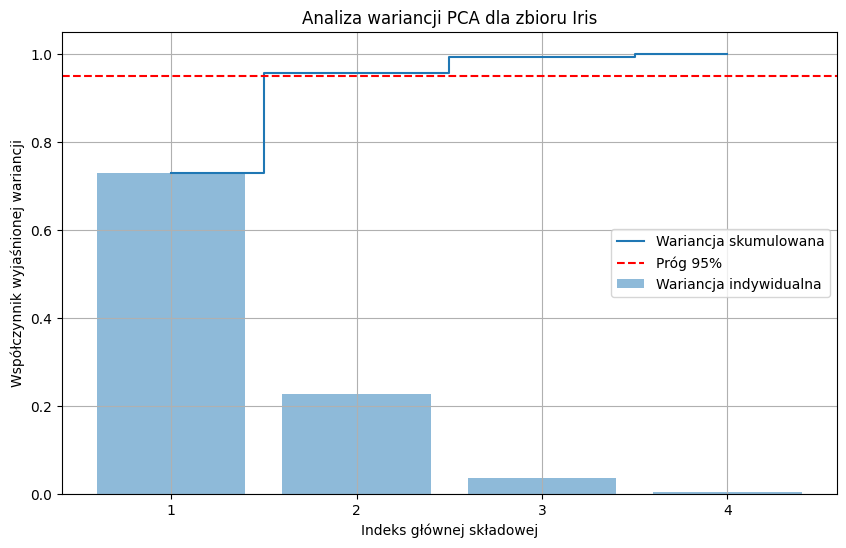

Liczba składowych potrzebna do wyjaśnienia 95% wariancji: 2
Wariancja skumulowana: [0.72962445 0.95813207 0.99482129 1.        ]


In [5]:
iris = load_iris()
X = iris.data

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_std)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

n_components_95 = np.argmax(cum_var >= 0.95) + 1

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, align='center', label='Wariancja indywidualna')
plt.step(range(1, len(cum_var) + 1), cum_var, where='mid', label='Wariancja skumulowana')
plt.axhline(y=0.95, color='r', linestyle='--', label='Próg 95%')
plt.ylabel('Współczynnik wyjaśnionej wariancji')
plt.xlabel('Indeks głównej składowej')
plt.xticks(range(1, len(exp_var) + 1))
plt.legend(loc='best')
plt.title('Analiza wariancji PCA dla zbioru Iris')
plt.grid()
plt.show()

print(f"Liczba składowych potrzebna do wyjaśnienia 95% wariancji: {n_components_95}")
print(f"Wariancja skumulowana: {cum_var}")

### zad 3

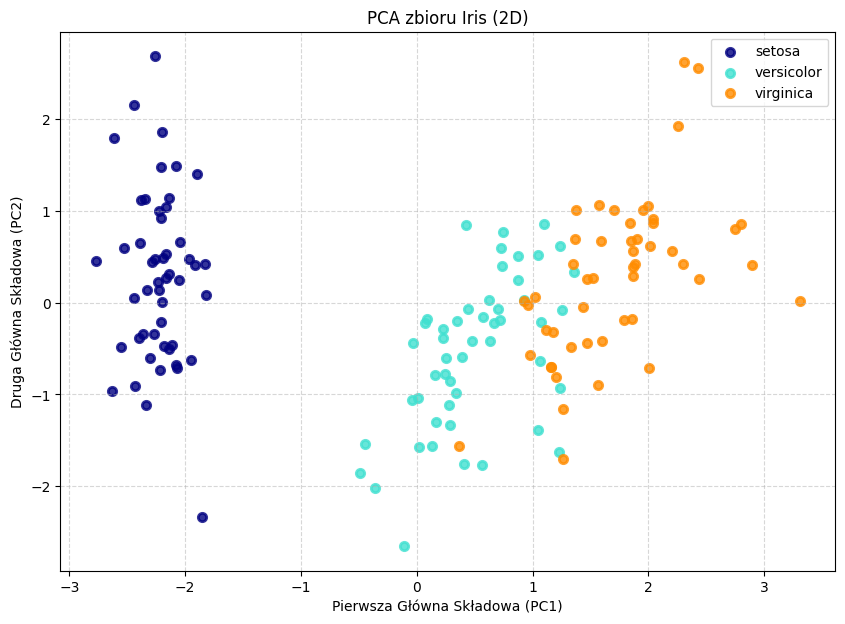

In [6]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10, 7))
colors = ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
                color=color, alpha=0.8, lw=2, label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA zbioru Iris (2D)')
plt.xlabel('Pierwsza Główna Składowa (PC1)')
plt.ylabel('Druga Główna Składowa (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### zad 3.1

In [7]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_full = LogisticRegression(random_state=42)
model_full.fit(X_train, y_train)
acc_full = model_full.score(X_test, y_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_pca = LogisticRegression(random_state=42)
model_pca.fit(X_train_pca, y_train)
acc_pca = model_pca.score(X_test_pca, y_test)

print(f"Dokładność (30 wymiarów): {acc_full:.2%}")
print(f"Dokładność (2 wymiary):   {acc_pca:.2%}")
print(f"Różnica:                  {acc_full - acc_pca:.2%}")


Dokładność (30 wymiarów): 98.25%
Dokładność (2 wymiary):   97.66%
Różnica:                  0.58%


### zad 4

In [8]:
data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

start_full = time.time()
model_full = LogisticRegression(random_state=42)
model_full.fit(X_train, y_train)
time_full = time.time() - start_full
acc_full = model_full.score(X_test, y_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

start_pca = time.time()
model_pca = LogisticRegression(random_state=42)
model_pca.fit(X_train_pca, y_train)
time_pca = time.time() - start_pca
acc_pca = model_pca.score(X_test_pca, y_test)

print(f"Pełne dane (13 cech) - Dokładność: {acc_full:.2%}, Czas: {time_full:.6f}s")
print(f"Dane PCA (2 cechy)   - Dokładność: {acc_pca:.2%}, Czas: {time_pca:.6f}s")

Pełne dane (13 cech) - Dokładność: 98.15%, Czas: 0.004919s
Dane PCA (2 cechy)   - Dokładność: 96.30%, Czas: 0.003540s


### zad 5

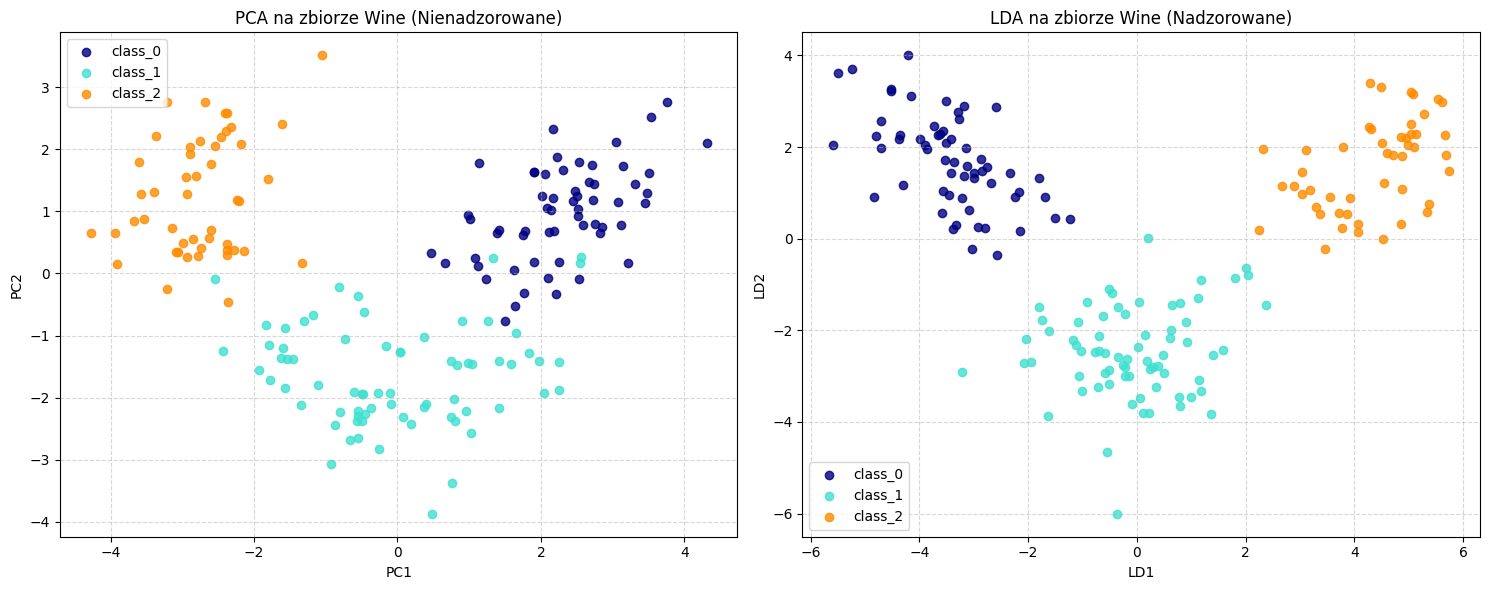

In [9]:
wine = load_wine()
X = wine.data
y = wine.target
target_names = wine.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    ax1.scatter(X_pca[y == i, 0], X_pca[y == i, 1], alpha=0.8, color=color, label=target_name)
    ax2.scatter(X_lda[y == i, 0], X_lda[y == i, 1], alpha=0.8, color=color, label=target_name)

ax1.set_title('PCA na zbiorze Wine (Nienadzorowane)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend(loc='best', shadow=False, scatterpoints=1)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.set_title('LDA na zbiorze Wine (Nadzorowane)')
ax2.set_xlabel('LD1')
ax2.set_ylabel('LD2')
ax2.legend(loc='best', shadow=False, scatterpoints=1)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### zad 6

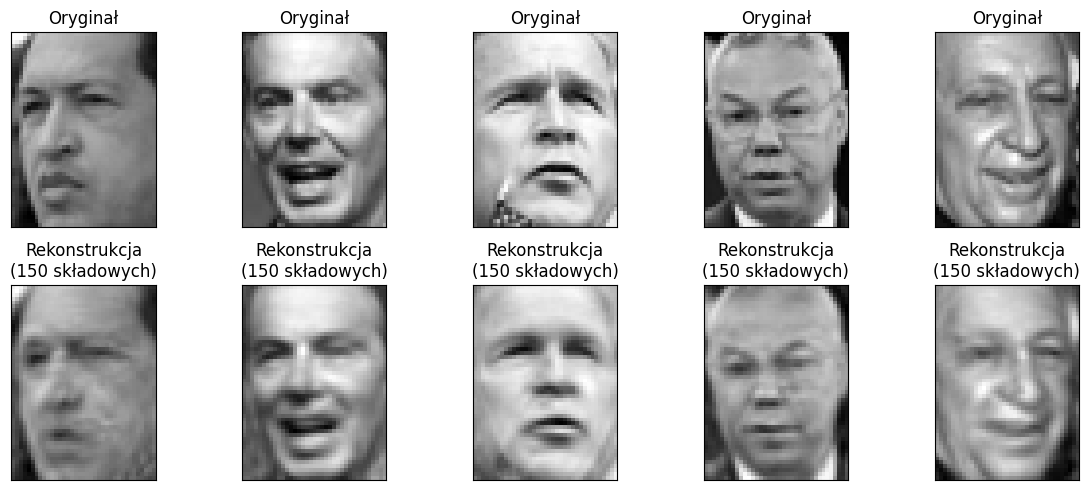

In [10]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
X = lfw_people.data
n_samples, h, w = lfw_people.images.shape

n_components = 150

pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X)

X_pca = pca.transform(X)
X_projected = pca.inverse_transform(X_pca)

fig, ax = plt.subplots(2, 5, figsize=(12, 5),
                       subplot_kw={'xticks': [], 'yticks': []})

for i in range(5):
    ax[0, i].imshow(X[i].reshape(h, w), cmap='gray')
    ax[0, i].set_title('Oryginał')
    
    ax[1, i].imshow(X_projected[i].reshape(h, w), cmap='gray')
    ax[1, i].set_title(f'Rekonstrukcja\n({n_components} składowych)')

plt.tight_layout()
plt.show()